
# Fundamentos y aplicación de ML en minería

**Sesión de clase:** Aprendizaje supervisado desde *data splitting*  
**Enfoque:** clasificación y regresión con `scikit-learn`  
**Contexto:** datos sintéticos inspirados en variables geometalúrgicas y de exploración minera

## Objetivos de aprendizaje
1. Construir una base de datos sintética con variables mineras realistas.
2. Aplicar la división entrenamiento/prueba sin fuga de información.
3. Desarrollar un caso de **clasificación** con **K-Nearest Neighbors (KNN)**.
4. Desarrollar un caso de **regresión** con **Linear Regression, Ridge y Lasso**.
5. Evaluar modelos con métricas apropiadas e interpretar resultados.

Este notebook sigue la lógica de la presentación:
- **División de datos**
- **KNN para clasificación**
- **Regresión lineal, Ridge y Lasso**
- **Métricas de desempeño**
- **Complejidad del modelo, sobreajuste y subajuste**

> Se usa una **data sintética** para que el ejemplo sea totalmente reproducible en clase, sin depender de descargas externas.


In [5]:
# ════════════════════════════════════════════════════════════
#  CELDA 1 — CONFIGURACIÓN INICIAL DEL ENTORNO
# ════════════════════════════════════════════════════════════

# ── Silenciar advertencias innecesarias ──────────────────────
import warnings
warnings.filterwarnings("ignore")
# Oculta mensajes de advertencia de Python para que la salida
# del notebook quede limpia durante la clase.

# ── Librerías numéricas y de datos ──────────────────────────
import numpy as np
# NumPy: operaciones matemáticas con arrays y matrices.
# También se usa para generar los datos sintéticos con 'rng'.

import pandas as pd
# Pandas: manejo de tablas (DataFrames).
# Es el "Excel" de Python — acá guardamos los datos mineros.

import matplotlib.pyplot as plt
# Matplotlib: para graficar resultados, métricas y distribuciones.

# ── Herramientas de división y validación ───────────────────
from sklearn.model_selection import (
    train_test_split,   # Divide datos en entrenamiento y prueba
    StratifiedKFold,    # Validación cruzada respetando proporción de clases
    KFold,              # Validación cruzada básica (para regresión)
    cross_val_score,    # Evalúa un modelo con validación cruzada automáticamente
)

# ── Pipeline: encadenar pasos sin fuga de información ───────
from sklearn.pipeline import make_pipeline
# Combina preprocesamiento + modelo en un solo objeto.
# Garantiza que el escalado se aprenda SOLO con datos de entrenamiento.

# ── Preprocesamiento ────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
# Estandariza variables → media=0, desviación estándar=1.
# Imprescindible para KNN, que mide distancias entre puntos:
# sin escalar, una variable en miles domina sobre una en decimales.

# ── Modelo de clasificación ─────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
# KNN (K vecinos más cercanos): clasifica un punto nuevo
# según la clase mayoritaria entre sus K vecinos más similares.
# Ejemplo minero: ¿este sondaje es mineral económico o estéril?

# ── Modelos de regresión ────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# Los tres predicen valores numéricos continuos.
# Ejemplo minero: predecir la ley de Cu (%) o recuperación metalúrgica.
#
#   LinearRegression → mínimos cuadrados clásico, sin restricciones
#   Ridge            → penaliza coeficientes grandes (regularización L2)
#                      útil cuando hay variables correlacionadas
#   Lasso            → puede llevar coeficientes a exactamente 0 (L1)
#                      útil para selección automática de variables

# ── Métricas de evaluación ──────────────────────────────────
from sklearn.metrics import (

    # — Clasificación —
    accuracy_score,         # % de muestras clasificadas correctamente
    classification_report,  # Tabla con precisión, recall y F1 por clase
    confusion_matrix,       # Matriz de aciertos y errores por clase
    ConfusionMatrixDisplay, # Versión visual (gráfico) de la matriz anterior

    # — Regresión —
    r2_score,               # R²: proporción de varianza explicada (ideal → 1.0)
    mean_absolute_error,    # MAE: error promedio en las unidades originales
    root_mean_squared_error,# RMSE: igual pero penaliza más los errores grandes
)

import os
# ── Reproducibilidad ────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)
# La semilla fija el generador de números aleatorios.
# Con SEED=42 siempre se generan los mismos datos sintéticos
# y los mismos splits → todos en clase obtienen idénticos resultados.

# ── Formato de visualización de tablas ──────────────────────
pd.set_option("display.max_columns", 100)  # Muestra hasta 100 columnas
pd.set_option("display.precision", 3)      # Redondea a 3 decimales


## 1. Generación de datos sintéticos con contexto minero

Se simulan variables que podrían aparecer en campañas de exploración o en estudios geometalúrgicos:
- profundidad
- ley de cobre
- dureza
- densidad
- fracturamiento
- humedad
- contenido de sílice
- alteración hidrotermal
- ruido instrumental

A partir de estas variables se construyen dos problemas:
1. **Clasificación:** prioridad geometalúrgica (`baja`, `media`, `alta`)
2. **Regresión:** recuperación metalúrgica estimada (%)


In [6]:

n = 650

profundidad_m = rng.uniform(20, 600, n)
ley_cu_pct = np.clip(rng.normal(0.95, 0.28, n), 0.25, 2.2)
dureza_mohs = rng.uniform(2.5, 7.8, n)
densidad_t_m3 = rng.uniform(2.1, 3.5, n)
fracturamiento = rng.uniform(0.05, 0.98, n)
humedad_pct = rng.uniform(0.5, 14.0, n)
silice_pct = rng.uniform(18, 72, n)
alteracion_hidrotermal = rng.uniform(0.0, 1.0, n)
sensor_ruido = rng.normal(0, 1, n)
ley_eq_pct = np.clip(0.82 * ley_cu_pct + rng.normal(0, 0.08, n), 0.15, None)
indice_fragmentacion = np.clip(60 * fracturamiento - 4.5 * dureza_mohs + rng.normal(0, 4, n), 0, 100)

score_clase = (
    3.2 * ley_cu_pct
    + 1.8 * fracturamiento
    + 0.9 * alteracion_hidrotermal
    - 0.42 * dureza_mohs
    - 0.0035 * profundidad_m
    - 0.016 * silice_pct
    + 0.010 * indice_fragmentacion
    + rng.normal(0, 0.18, n)
)

q1, q2 = np.quantile(score_clase, [0.33, 0.66])
prioridad = np.select(
    [score_clase <= q1, score_clase <= q2],
    ["baja", "media"],
    default="alta"
)

recuperacion_pct = (
    52
    + 18 * ley_cu_pct
    + 4.5 * fracturamiento
    + 3.2 * alteracion_hidrotermal
    - 1.9 * dureza_mohs
    - 0.12 * silice_pct
    - 0.22 * humedad_pct
    + 1.8 * ley_eq_pct
    + 0.035 * indice_fragmentacion
    + 1.5 * densidad_t_m3
    + rng.normal(0, 2.4, n)
)
recuperacion_pct = np.clip(recuperacion_pct, 35, 95)

df = pd.DataFrame({
    "profundidad_m": profundidad_m,
    "ley_cu_pct": ley_cu_pct,
    "ley_eq_pct": ley_eq_pct,
    "dureza_mohs": dureza_mohs,
    "densidad_t_m3": densidad_t_m3,
    "fracturamiento": fracturamiento,
    "humedad_pct": humedad_pct,
    "silice_pct": silice_pct,
    "alteracion_hidrotermal": alteracion_hidrotermal,
    "indice_fragmentacion": indice_fragmentacion,
    "sensor_ruido": sensor_ruido,
    "prioridad_geometalurgica": prioridad,
    "recuperacion_pct": recuperacion_pct,
})

csv_path = "DSMining_notebooks/datos_sinteticos_mineria.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)  # ← add this line

df.to_csv(csv_path, index=False)

print(f"Dimensión del dataset: {df.shape}")
print(f"Archivo CSV guardado en: {csv_path}")
df.head()


Dimensión del dataset: (650, 13)
Archivo CSV guardado en: DSMining_notebooks/datos_sinteticos_mineria.csv


,profundidad_m,ley_cu_pct,ley_eq_pct,dureza_mohs,densidad_t_m3,fracturamiento,humedad_pct,silice_pct,alteracion_hidrotermal,indice_fragmentacion,sensor_ruido,prioridad_geometalurgica,recuperacion_pct
0,468.895,0.801,0.718,2.524,2.315,0.769,6.941,38.864,0.814,34.486,0.305,alta,68.051
1,274.549,0.835,0.775,2.704,3.136,0.302,5.072,39.379,0.160,0.363,0.480,media,62.902
2,517.987,1.332,1.139,6.106,2.205,0.510,3.579,34.465,0.661,4.643,-1.340,media,66.638
3,424.473,0.659,0.592,5.482,3.122,0.234,3.049,46.010,0.755,0.000,-0.001,baja,58.245
4,74.623,0.274,0.267,2.641,3.289,0.851,10.806,47.422,0.037,46.812,0.509,media,56.816


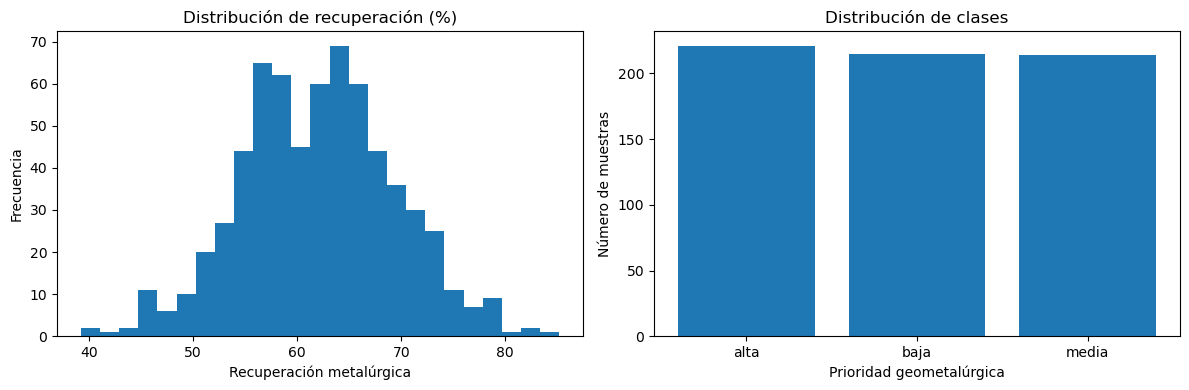

,count,mean,std,min,25%,50%,75%,max
profundidad_m,650.0,310.905,168.049,2.261e+01,158.691,313.225,462.109,599.481
ley_cu_pct,650.0,0.946,0.279,2.500e-01,0.762,0.951,1.127,1.840
ley_eq_pct,650.0,0.782,0.247,1.500e-01,0.614,0.777,0.941,1.549
dureza_mohs,650.0,5.211,1.544,2.503e+00,3.806,5.148,6.606,7.794
densidad_t_m3,650.0,2.784,0.407,2.105e+00,2.447,2.781,3.134,3.500
fracturamiento,650.0,0.511,0.272,5.077e-02,0.269,0.510,0.743,0.979
humedad_pct,650.0,7.342,3.861,5.087e-01,4.237,7.402,10.703,13.992
silice_pct,650.0,44.008,15.512,1.809e+01,30.649,43.975,57.190,71.906
alteracion_hidrotermal,650.0,0.477,0.279,9.261e-04,0.236,0.455,0.699,1.000
indice_fragmentacion,650.0,11.645,13.147,0.000e+00,0.000,6.904,22.248,50.598


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["recuperacion_pct"], bins=25)
axes[0].set_title("Distribución de recuperación (%)")
axes[0].set_xlabel("Recuperación metalúrgica")
axes[0].set_ylabel("Frecuencia")

conteo_clases = df["prioridad_geometalurgica"].value_counts().sort_index()
axes[1].bar(conteo_clases.index, conteo_clases.values)
axes[1].set_title("Distribución de clases")
axes[1].set_xlabel("Prioridad geometalúrgica")
axes[1].set_ylabel("Número de muestras")

plt.tight_layout()
plt.show()

df.describe().T



## 2. Caso de clasificación: K-Nearest Neighbors (KNN)

La variable objetivo será `prioridad_geometalurgica`.

### Idea metodológica
1. Separar `X` e `y`.
2. Aplicar `train_test_split` con estratificación.
3. Estandarizar variables dentro de un `Pipeline`.
4. Evaluar distintos valores de `k` con validación cruzada sobre el conjunto de entrenamiento.
5. Entrenar el modelo final y evaluar en el conjunto de prueba.


In [8]:

features = [
    "profundidad_m",
    "ley_cu_pct",
    "ley_eq_pct",
    "dureza_mohs",
    "densidad_t_m3",
    "fracturamiento",
    "humedad_pct",
    "silice_pct",
    "alteracion_hidrotermal",
    "indice_fragmentacion",
    "sensor_ruido",
]

X_cls = df[features]
y_cls = df["prioridad_geometalurgica"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=SEED,
    stratify=y_cls,
)

print("Tamaño entrenamiento:", X_train_cls.shape)
print("Tamaño prueba:", X_test_cls.shape)
print("Distribución entrenamiento:")
print(y_train_cls.value_counts(normalize=True).sort_index().round(3))
print("\nDistribución prueba:")
print(y_test_cls.value_counts(normalize=True).sort_index().round(3))


Tamaño entrenamiento: (520, 11)
Tamaño prueba: (130, 11)
Distribución entrenamiento:
prioridad_geometalurgica
alta     0.340
baja     0.331
media    0.329
Name: proportion, dtype: float64

Distribución prueba:
prioridad_geometalurgica
alta     0.338
baja     0.331
media    0.331
Name: proportion, dtype: float64


In [9]:

ks = range(1, 26)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_knn = []

for k in ks:
    modelo = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    modelo.fit(X_train_cls, y_train_cls)

    acc_train = accuracy_score(y_train_cls, modelo.predict(X_train_cls))
    acc_cv = cross_val_score(modelo, X_train_cls, y_train_cls, cv=cv, scoring="accuracy").mean()

    resultados_knn.append({
        "k": k,
        "accuracy_train": acc_train,
        "accuracy_cv": acc_cv,
    })

resultados_knn = pd.DataFrame(resultados_knn)
best_k = int(resultados_knn.loc[resultados_knn["accuracy_cv"].idxmax(), "k"])
print(f"Mejor k según validación cruzada: {best_k}")
resultados_knn.head()


Mejor k según validación cruzada: 21


,k,accuracy_train,accuracy_cv
0,1,1.000,0.681
1,2,0.858,0.646
2,3,0.858,0.677
3,4,0.854,0.723
4,5,0.802,0.696


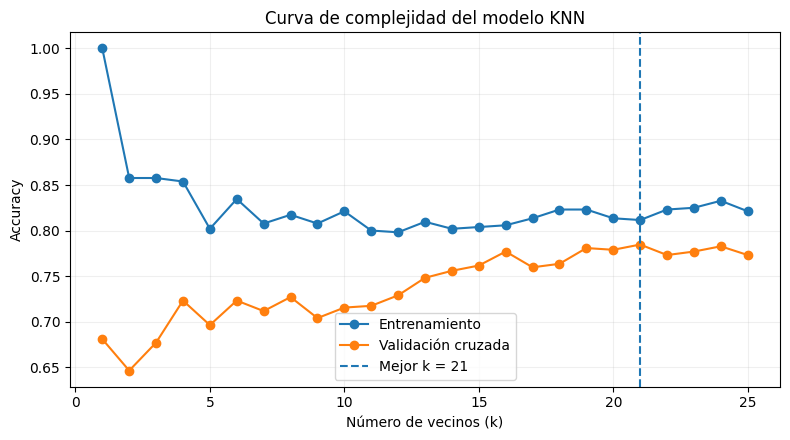

,k,accuracy_train,accuracy_cv
20,21,0.812,0.785
23,24,0.833,0.783
18,19,0.823,0.781
19,20,0.813,0.779
15,16,0.806,0.777
22,23,0.825,0.777
21,22,0.823,0.773
24,25,0.821,0.773
17,18,0.823,0.763
14,15,0.804,0.762


In [6]:

plt.figure(figsize=(8, 4.5))
plt.plot(resultados_knn["k"], resultados_knn["accuracy_train"], marker="o", label="Entrenamiento")
plt.plot(resultados_knn["k"], resultados_knn["accuracy_cv"], marker="o", label="Validación cruzada")
plt.axvline(best_k, linestyle="--", label=f"Mejor k = {best_k}")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.title("Curva de complejidad del modelo KNN")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

resultados_knn.sort_values("accuracy_cv", ascending=False).head(10)


Accuracy en prueba: 0.808

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.85      0.89      0.87        44
        baja       0.84      0.86      0.85        43
       media       0.72      0.67      0.70        43

    accuracy                           0.81       130
   macro avg       0.80      0.81      0.81       130
weighted avg       0.80      0.81      0.81       130



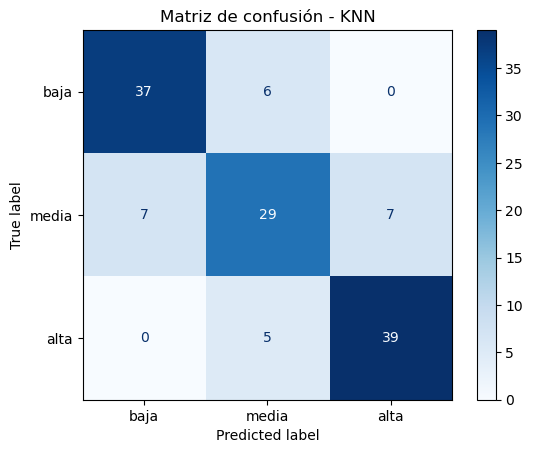

In [10]:

knn_final = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k)
)
knn_final.fit(X_train_cls, y_train_cls)

y_pred_cls = knn_final.predict(X_test_cls)
acc_test = accuracy_score(y_test_cls, y_pred_cls)

print(f"Accuracy en prueba: {acc_test:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_cls, y_pred_cls))

cm = confusion_matrix(y_test_cls, y_pred_cls, labels=["baja", "media", "alta"])
ConfusionMatrixDisplay(cm, display_labels=["baja", "media", "alta"]).plot(cmap="Blues")
plt.title("Matriz de confusión - KNN")
plt.show()



### Comentario didáctico
- Cuando **k es muy pequeño**, el modelo puede memorizar el entrenamiento y sobreajustar.
- Cuando **k es muy grande**, el modelo suaviza demasiado la frontera de decisión y puede subajustar.
- La curva anterior permite discutir la relación entre **complejidad del modelo** y **capacidad de generalización**.



## 3. Caso de regresión: recuperación metalúrgica (%)

Ahora la variable objetivo será `recuperacion_pct`.

Se compararán tres modelos:
- **Linear Regression (OLS)**
- **Ridge**
- **Lasso**

Todos se entrenarán dentro de un `Pipeline` con `StandardScaler`.


In [20]:

X_reg = df[features]
y_reg = df["recuperacion_pct"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=SEED,
)

print("Tamaño entrenamiento:", X_train_reg.shape)
print("Tamaño prueba:", X_test_reg.shape)


Tamaño entrenamiento: (520, 11)
Tamaño prueba: (130, 11)


In [21]:

def evaluar_regresion(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
        "RMSE_test": root_mean_squared_error(y_test, pred_test),
        "MAE_test": mean_absolute_error(y_test, pred_test),
    }


In [22]:

alphas_ridge = np.logspace(-3, 2, 25)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

ridge_curve = []
for alpha in alphas_ridge:
    modelo = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    modelo.fit(X_train_reg, y_train_reg)
    r2_train = r2_score(y_train_reg, modelo.predict(X_train_reg))
    r2_cv = cross_val_score(modelo, X_train_reg, y_train_reg, cv=cv_reg, scoring="r2").mean()
    ridge_curve.append({"alpha": alpha, "R2_train": r2_train, "R2_cv": r2_cv})

ridge_curve = pd.DataFrame(ridge_curve)
best_alpha_ridge = float(ridge_curve.loc[ridge_curve["R2_cv"].idxmax(), "alpha"])
print(f"Mejor alpha para Ridge: {best_alpha_ridge:.4f}")


Mejor alpha para Ridge: 2.1544


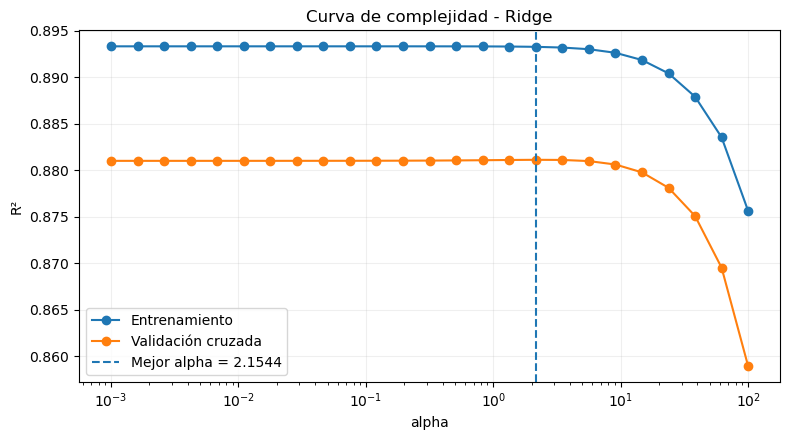

In [23]:

plt.figure(figsize=(8, 4.5))
plt.semilogx(ridge_curve["alpha"], ridge_curve["R2_train"], marker="o", label="Entrenamiento")
plt.semilogx(ridge_curve["alpha"], ridge_curve["R2_cv"], marker="o", label="Validación cruzada")
plt.axvline(best_alpha_ridge, linestyle="--", label=f"Mejor alpha = {best_alpha_ridge:.4f}")
plt.xlabel("alpha")
plt.ylabel("R²")
plt.title("Curva de complejidad - Ridge")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [15]:

alphas_lasso = np.logspace(-3, 0.8, 22)
lasso_curve = []
for alpha in alphas_lasso:
    modelo = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=20000))
    modelo.fit(X_train_reg, y_train_reg)
    r2_train = r2_score(y_train_reg, modelo.predict(X_train_reg))
    r2_cv = cross_val_score(modelo, X_train_reg, y_train_reg, cv=cv_reg, scoring="r2").mean()
    lasso_curve.append({"alpha": alpha, "R2_train": r2_train, "R2_cv": r2_cv})

lasso_curve = pd.DataFrame(lasso_curve)
best_alpha_lasso = float(lasso_curve.loc[lasso_curve["R2_cv"].idxmax(), "alpha"])
print(f"Mejor alpha para Lasso: {best_alpha_lasso:.4f}")


Mejor alpha para Lasso: 0.0010


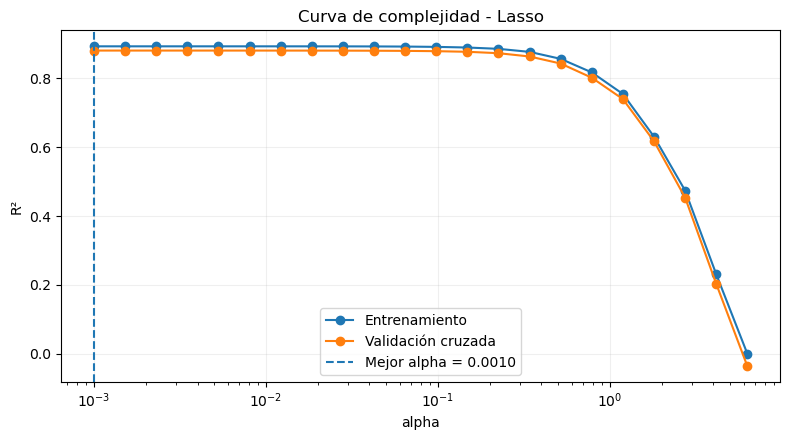

In [16]:

plt.figure(figsize=(8, 4.5))
plt.semilogx(lasso_curve["alpha"], lasso_curve["R2_train"], marker="o", label="Entrenamiento")
plt.semilogx(lasso_curve["alpha"], lasso_curve["R2_cv"], marker="o", label="Validación cruzada")
plt.axvline(best_alpha_lasso, linestyle="--", label=f"Mejor alpha = {best_alpha_lasso:.4f}")
plt.xlabel("alpha")
plt.ylabel("R²")
plt.title("Curva de complejidad - Lasso")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [17]:

modelos_reg = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=best_alpha_ridge)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=best_alpha_lasso, max_iter=20000)),
}

metricas_reg = []
modelos_ajustados = {}

for nombre, modelo in modelos_reg.items():
    metricas_reg.append(evaluar_regresion(nombre, modelo, X_train_reg, X_test_reg, y_train_reg, y_test_reg))
    modelo.fit(X_train_reg, y_train_reg)
    modelos_ajustados[nombre] = modelo

metricas_reg = pd.DataFrame(metricas_reg).sort_values("R2_test", ascending=False)
metricas_reg


,modelo,R2_train,R2_test,RMSE_test,MAE_test
1,Ridge,0.893,0.91,2.304,1.864
2,Lasso,0.893,0.91,2.308,1.865
0,OLS,0.893,0.91,2.309,1.866


In [18]:

coeficientes = pd.DataFrame({"variable": features})

for nombre, modelo in modelos_ajustados.items():
    coefs = modelo.named_steps[list(modelo.named_steps.keys())[-1]].coef_
    coeficientes[nombre] = coefs

coeficientes.sort_values("Ridge", key=np.abs, ascending=False)


,variable,OLS,Ridge,Lasso
1,ley_cu_pct,4.786,4.643,4.788
3,dureza_mohs,-2.970,-2.948,-2.969
7,silice_pct,-1.949,-1.941,-1.948
5,fracturamiento,1.321,1.282,1.320
8,alteracion_hidrotermal,0.906,0.905,0.905
6,humedad_pct,-0.852,-0.849,-0.852
2,ley_eq_pct,0.570,0.702,0.566
4,densidad_t_m3,0.564,0.561,0.563
9,indice_fragmentacion,0.383,0.419,0.383
10,sensor_ruido,0.124,0.125,0.124


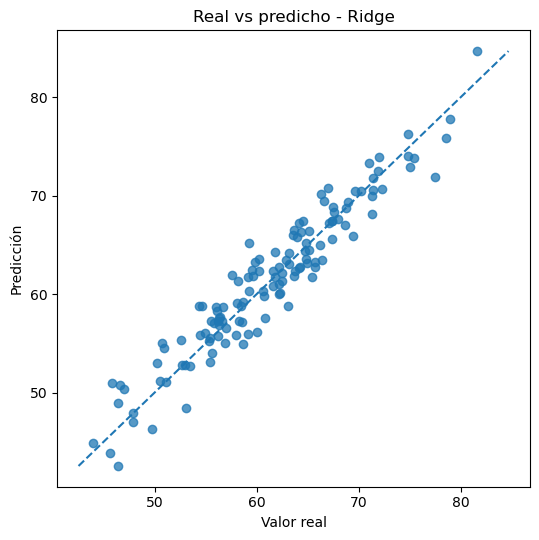

In [19]:

mejor_modelo_nombre = metricas_reg.iloc[0]["modelo"]
mejor_modelo = modelos_ajustados[mejor_modelo_nombre]
pred_best = mejor_modelo.predict(X_test_reg)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test_reg, pred_best, alpha=0.75)
lims = [min(y_test_reg.min(), pred_best.min()), max(y_test_reg.max(), pred_best.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Real vs predicho - {mejor_modelo_nombre}")
plt.tight_layout()
plt.show()



## 4. Conclusiones para la clase

### Clasificación
- KNN funciona bien cuando la estructura de clases está reflejada en la proximidad entre observaciones.
- El valor de `k` controla la complejidad del modelo.
- El escalado es importante porque KNN usa distancias.

### Regresión
- OLS es un buen punto de partida cuando la relación es aproximadamente lineal.
- Ridge penaliza coeficientes grandes y suele ser útil cuando hay correlación entre variables predictoras.
- Lasso puede reducir coeficientes poco útiles y apoyar una discusión inicial sobre selección de variables.

### Mensaje metodológico clave
La secuencia correcta no es solamente “entrenar un modelo”, sino:
1. Definir variables predictoras y objetivo.
2. Dividir datos en entrenamiento y prueba.
3. Ajustar preprocesamiento usando solo entrenamiento.
4. Validar el modelo.
5. Evaluar finalmente en datos no vistos.



## 5. Posibles extensiones para práctica
- Reemplazar KNN por `DecisionTreeClassifier` o `RandomForestClassifier`.
- Comparar métricas de clasificación: accuracy, precision, recall y F1.
- Comparar métricas de regresión: R², RMSE y MAE.
